# Recategorize BIM Features
This notebook is based on the workflow in the [Enhance a building layer to support downstream workflows](https://www.esri.com/arcgis-blog/products/arcgis-pro/aec/enhance-a-building-layer-to-support-downstream-workflows) blog article. This sample shows how to move features in the Generic Model feature class into new and existing categorized feature classes.

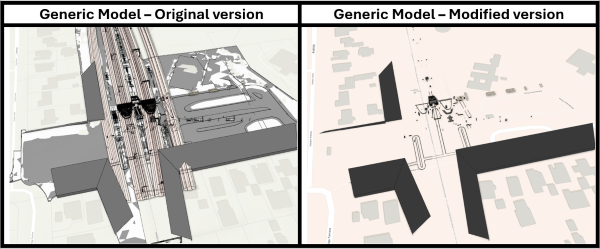

## Use case

As a GIS analyst on a facility management team, you need to author a scene for teammates to use. The scene includes BIM‑derived feature layers.  

After combining multiple BIM models into a single feature dataset for your scene, you notice that many elements are classified in the Generic Model feature layer. You now must reclassify and structure model elements so the feature layers meaningfully support operations, maintenance, and asset reporting in GIS. This sample shows how to move features from the Generic Model feature class into new and existing categorized feature classes based on the Revit family name stored in the Family attribute field.


## Requirements

Create a single feature dataset from one or more BIM models using the **BIM File to Geodatabase** geoprocessing tool. For more information on how to combine BIM models, check out the [Combine multiple digital models into a single building scene layer](https://www.esri.com/arcgis-blog/products/arcgis-pro/aec/combine-multiple-digital-models-into-a-single-building-scene-layer) blog article.

## Use the sample
Download the Jupyter notebook, adjust the data path, and follow the steps below.


#### Prepare variables

In [ ]:
# Import necessary modules
import arcpy
import os

In [ ]:
# Set input paths and project settings
input_feature_dataset = r'C:\Projects\MyProjectName\MyProject.gdb\MyFeatureDatasetName'
arcpy.env.workspace = input_feature_dataset
arcpy.env.overwriteOutput = True
arcpy.env.addOutputsToMap = False

project_suffix = os.path.split(input_feature_dataset)[1]

# Use the value of the Family field to categorize the elements from the source feature class
# The Family field is populated from the Revit family name
filter_field = 'Family'

# Generic Model feature class name
generic_model_fc = f'GenericModel_{project_suffix}'

#### Map field values to feature class names
Identify the values of the Family field that align with target feature class names. If the feature class does not exist, a new one will be created. 

| Family Field Value | Target Feature Class Name |
| :--- | :--- |
| _CUSTOM TILE WALL | Walls |
| 00_Shared Pod Glazing | Walls |
| 79_Escalator_Travelator_JX | SpecialtyEquipment |
| CRL_57_FUR_4 Seat Bench_JHR | FurnitureSystem |
| 79_Lift_Door_w_Shaft_Pln_JX | Doors |
| Thale High Swing Gates | Doors |
| 57_STATION Rubbish Bin | RubbishBin *(new feature class)* |

Create a dictionary from your list above.

In [ ]:
mapping_dict = {
    'Walls': [
        '_CUSTOM TILE WALL',
        '00_Shared Pod Glazing'
    ],
    'SpecialtyEquipment': [
        '79_Escalator_Travelator_JX'
    ],
    'FurnitureSystem': [
        'CRL_57_FUR_4 Seat Bench_JHR'
    ],
    'Doors': [
        '79_Lift_Door_w_Shaft_Pln_JX',
        'Thale High Swing Gates'
    ],
    'RubbishBin': [
        '57_STATION Rubbish Bin'
    ], # New feature class will be created
}

#### Move features into specific feature classes using values of the Family field 


In [ ]:
def move_features(
    input_dataset,
    source_fc,
    mapping_dict,
    filter_field,
    project_suffix
):
    """
    For each key in mapping_dict:
      - If target feature class exists, append matching features from source_fc.
      - Else, create new feature class (with alias), then append.
      - Delete appended features from source_fc.
    """
    fc_list = arcpy.ListFeatureClasses()
    for key, family_list in mapping_dict.items():
        print(f"Processing: {key}")
        target_fc = f"{key}_{project_suffix}"
        # Build where clause for selection
        field_value = next((fam for fam in family_list if fam and '%' in fam), None)
        if field_value:
            where_clause = f"{filter_field} LIKE '{field_value}'"
        else:
            values = [f"'{fam}'" for fam in family_list if fam]
            if values:
                where_clause = f"{filter_field} IN ({', '.join(values)})"
            else:
                where_clause = f"{filter_field} = '___NO_MATCH___'"

        # Create target feature class if missing
        if target_fc not in fc_list:
            arcpy.CreateFeatureclass_management(
                out_path=input_dataset,
                out_name=target_fc,
                geometry_type=arcpy.Describe(source_fc).shapeType,
                template=source_fc,
                spatial_reference=arcpy.Describe(source_fc).spatialReference
            )
            arcpy.AlterAliasName(target_fc, key)

        # Select and append features
        arcpy.MakeFeatureLayer_management(source_fc, "src_lyr", where_clause)
        arcpy.Append_management("src_lyr", target_fc, "NO_TEST")
        # Delete selected features from source_fc
        arcpy.SelectLayerByAttribute_management("src_lyr", "NEW_SELECTION", where_clause)
        arcpy.DeleteFeatures_management("src_lyr")
        arcpy.Delete_management("src_lyr")
    print("\nAll mapping keys processed.")

In [ ]:
# Move features from GenericModel
move_features(
    input_dataset=input_feature_dataset,
    source_fc=generic_model_fc,
    mapping_dict=mapping_dict,
    filter_field=filter_field,
    project_suffix=project_suffix
)